In [1]:
# ========================================
# 01_EDA.ipynb
# Smart Factory Power Analysis - EDA
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import drive
import os

# Drive Mount
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Projects/smart-factory-power')
print(f"✅ 작업 디렉토리: {os.getcwd()}")

Mounted at /content/drive
✅ 작업 디렉토리: /content/drive/MyDrive/Projects/smart-factory-power


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 118 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 59s (176 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
사용 가능한 폰트: ['NanumGothic', 'Nanum

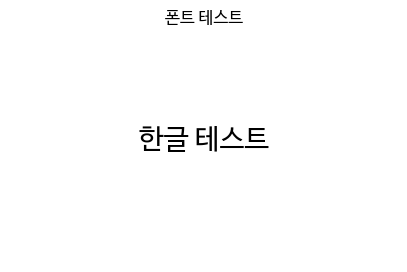


✅ 한글 폰트 설정 완료!


In [2]:
# ========================================
# 한글 폰트 설정
# ========================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 나눔폰트 설치 (이미 됐지만 재확인)
!apt-get update -qq
!apt-get install -y fonts-nanum

# 2. 폰트 경로 직접 추가
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

# 3. matplotlib 캐시 완전 삭제
!rm -rf ~/.cache/matplotlib/*
!rm -rf ~/.config/matplotlib/*

# 4. 폰트 매니저 재로드
fm._load_fontmanager(try_read_cache=False)

# 5. 사용 가능한 폰트 확인
fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("사용 가능한 폰트:", fonts)

# 6. 폰트 설정
if fonts:
    plt.rcParams['font.family'] = fonts[3]
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ 폰트 설정 완료: {fonts[0]}")
else:
    print("⚠️ 나눔폰트를 찾을 수 없습니다.")

# 7. 테스트
fig, ax = plt.subplots(figsize=(5, 3))
ax.text(0.5, 0.5, '한글 테스트', fontsize=20, ha='center')
ax.set_title('폰트 테스트')
plt.axis('off')
plt.show()

print("\n✅ 한글 폰트 설정 완료!")

In [3]:
# ========================================
# 데이터 로드
# ========================================

print("\n[데이터 로드]")
df_train = pd.read_csv('./data/processed/module1/train.csv')
df_test = pd.read_csv('./data/processed/module1/test.csv')

# datetime 변환
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_test['datetime'] = pd.to_datetime(df_test['datetime'])

print(f"Train: {df_train.shape}")
print(f"Test: {df_test.shape}")
print(f"Train 데이터 기간: {df_train['datetime'].min()} ~ {df_train['datetime'].max()}")
print(f"Test 데이터 기간: {df_test['datetime'].min()} ~ {df_test['datetime'].max()}")


[데이터 로드]
Train: (2085840, 20)
Test: (506161, 20)
Train 데이터 기간: 2024-12-01 08:00:00 ~ 2025-03-31 23:59:55
Test 데이터 기간: 2025-04-01 00:00:00 ~ 2025-04-30 07:00:00


In [5]:
# ========================================
# src 함수 로드 및 1시간 집계
# ========================================
from src.eda.aggregation import aggregate_to_hourly

print("\n[1시간 단위 집계]")
df_train_hourly = aggregate_to_hourly(df_train)
df_test_hourly = aggregate_to_hourly(df_test)

print(f"Train Hourly: {df_train_hourly.shape}")
print(f"Test Hourly: {df_test_hourly.shape}")

# 저장
hourly_dir = './data/processed/hourly/'
os.makedirs(hourly_dir, exist_ok=True)

df_train_hourly.to_csv(f'{hourly_dir}train.csv', index=False)
df_test_hourly.to_csv(f'{hourly_dir}test.csv', index=False)

print(f"\n✅ 저장 완료: {hourly_dir}")

# 미리보기
print("\n[집계 결과 미리보기]")
print(df_train_hourly.head())
print("\n기술 통계:")
print(df_train_hourly[['activePower_mean', 'activePower_std',
                       'activePower_min', 'activePower_max']].describe())

print("\n✅ 1시간 집계 완료!")


[1시간 단위 집계]
Train Hourly: (2896, 25)
Test Hourly: (704, 25)

✅ 저장 완료: ./data/processed/hourly/

[집계 결과 미리보기]
             datetime  activePower_mean  activePower_std  activePower_min  \
0 2024-12-01 08:00:00       3011.903014       738.202090          1051.34   
1 2024-12-01 09:00:00       3011.384833       736.284029          1126.53   
2 2024-12-01 10:00:00       2990.481861       710.641426          1046.87   
3 2024-12-01 11:00:00       3003.309125       721.679595          1158.87   
4 2024-12-01 12:00:00       3007.081417       709.555132          1109.05   

   activePower_max  activePower_count    voltageR    voltageS    voltageT  \
0          5013.27                720  214.942208  215.099639  215.087583   
1          5096.31                720  215.008472  215.164583  214.659667   
2          4971.15                720  214.989569  215.172931  215.118292   
3          4855.11                720  214.940111  215.070264  215.064778   
4          4913.54                720  214

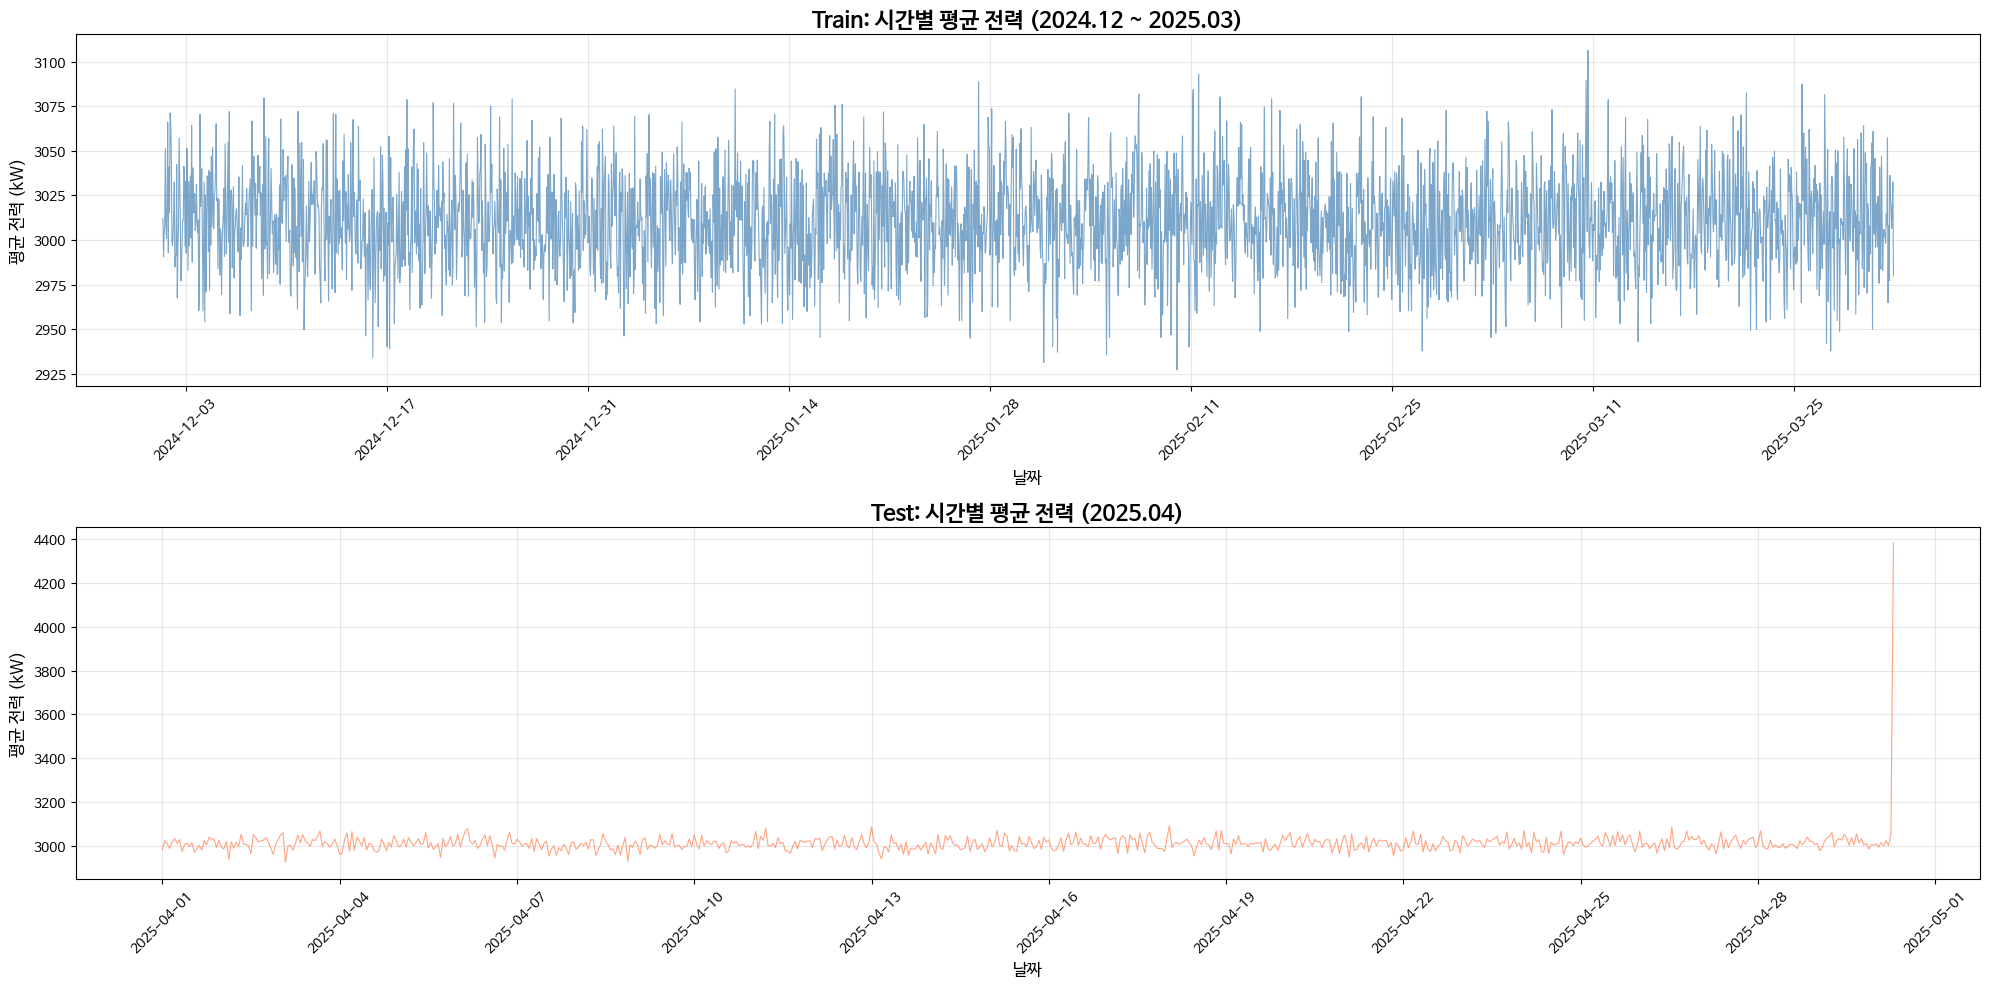


[전체 시계열 통계]
Train 평균: 3010.25 kW
Train 표준편차: 26.73 kW
Train 최소: 2927.12 kW
Train 최대: 3106.27 kW
Train 범위: 179.16 kW


In [6]:
# ========================================
# 1. 전체 시계열 시각화
# ========================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Train 데이터
axes[0].plot(df_train_hourly['datetime'],
             df_train_hourly['activePower_mean'],
             linewidth=0.8, alpha=0.7, color='steelblue')
axes[0].set_title('Train: 시간별 평균 전력 (2024.12 ~ 2025.03)',
                  fontsize=16, weight='bold')
axes[0].set_xlabel('날짜', fontsize=12)
axes[0].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Test 데이터
axes[1].plot(df_test_hourly['datetime'],
             df_test_hourly['activePower_mean'],
             linewidth=0.8, alpha=0.7, color='coral')
axes[1].set_title('Test: 시간별 평균 전력 (2025.04)',
                  fontsize=16, weight='bold')
axes[1].set_xlabel('날짜', fontsize=12)
axes[1].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

# 저장
os.makedirs('./results/figures', exist_ok=True)
plt.savefig('./results/figures/01_timeseries_overview.png',
            dpi=300, bbox_inches='tight')
plt.show()

# 기본 통계
print("\n[전체 시계열 통계]")
print(f"Train 평균: {df_train_hourly['activePower_mean'].mean():.2f} kW")
print(f"Train 표준편차: {df_train_hourly['activePower_mean'].std():.2f} kW")
print(f"Train 최소: {df_train_hourly['activePower_mean'].min():.2f} kW")
print(f"Train 최대: {df_train_hourly['activePower_mean'].max():.2f} kW")
print(f"Train 범위: {df_train_hourly['activePower_mean'].max() - df_train_hourly['activePower_mean'].min():.2f} kW")

In [7]:
# ========================================
# Test 데이터 마지막 이상치 확인
# ========================================

print("="*60)
print("🔍 Test 데이터 이상치 확인")
print("="*60)

# 4월 30일 데이터 확인
df_test_0430 = df_test_hourly[df_test_hourly['datetime'].dt.date == pd.to_datetime('2025-04-30').date()]

print("\n[4월 30일 데이터]")
print(f"행 수: {len(df_test_0430)}")
print(f"\n시간별 전력:")
print(df_test_0430[['datetime', 'activePower_mean', 'activePower_min', 'activePower_max']])

# 마지막 시간대 확인
print(f"\n마지막 시간: {df_test_hourly['datetime'].max()}")
print(f"마지막 전력: {df_test_hourly['activePower_mean'].iloc[-1]:.2f} kW")

# 전체 통계
print("\n[Test 전체 통계]")
print(df_test_hourly['activePower_mean'].describe())

# 이상치 확인 (3 sigma)
mean = df_test_hourly['activePower_mean'].mean()
std = df_test_hourly['activePower_mean'].std()
threshold_upper = mean + 3 * std
threshold_lower = mean - 3 * std

outliers = df_test_hourly[
    (df_test_hourly['activePower_mean'] > threshold_upper) |
    (df_test_hourly['activePower_mean'] < threshold_lower)
]

print(f"\n[이상치 (3σ 기준)]")
print(f"상한: {threshold_upper:.2f} kW")
print(f"하한: {threshold_lower:.2f} kW")
print(f"이상치 개수: {len(outliers)}개")

if len(outliers) > 0:
    print(f"\n이상치 목록:")
    print(outliers[['datetime', 'activePower_mean', 'activePower_min', 'activePower_max']])

🔍 Test 데이터 이상치 확인

[4월 30일 데이터]
행 수: 8

시간별 전력:
               datetime  activePower_mean  activePower_min  activePower_max
696 2025-04-30 00:00:00       3008.701333          1254.79          4907.48
697 2025-04-30 01:00:00       2994.501694           953.43          4987.61
698 2025-04-30 02:00:00       3015.529889          1351.98          4870.34
699 2025-04-30 03:00:00       2998.954292          1120.79          5017.83
700 2025-04-30 04:00:00       3023.869694          1132.53          4721.95
701 2025-04-30 05:00:00       3001.746319          1156.44          4829.26
702 2025-04-30 06:00:00       3056.720764          1279.14          4888.25
703 2025-04-30 07:00:00       4382.410000          4382.41          4382.41

마지막 시간: 2025-04-30 07:00:00
마지막 전력: 4382.41 kW

[Test 전체 통계]
count     704.000000
mean     3013.053379
std        57.915134
min      2924.088639
25%      2994.354826
50%      3009.800125
75%      3027.788236
max      4382.410000
Name: activePower_mean, dtype: float64

In [8]:
# 제거 및 저장
df_test_hourly = df_test_hourly[df_test_hourly['datetime'] < '2025-04-30 07:00:00'].copy()
df_test_hourly.to_csv('./data/processed/hourly/test.csv', index=False)

print("✅ 이상치 제거 및 저장 완료!")
print(f"최종 Test: {len(df_test_hourly)}시간")

✅ 이상치 제거 및 저장 완료!
최종 Test: 703시간


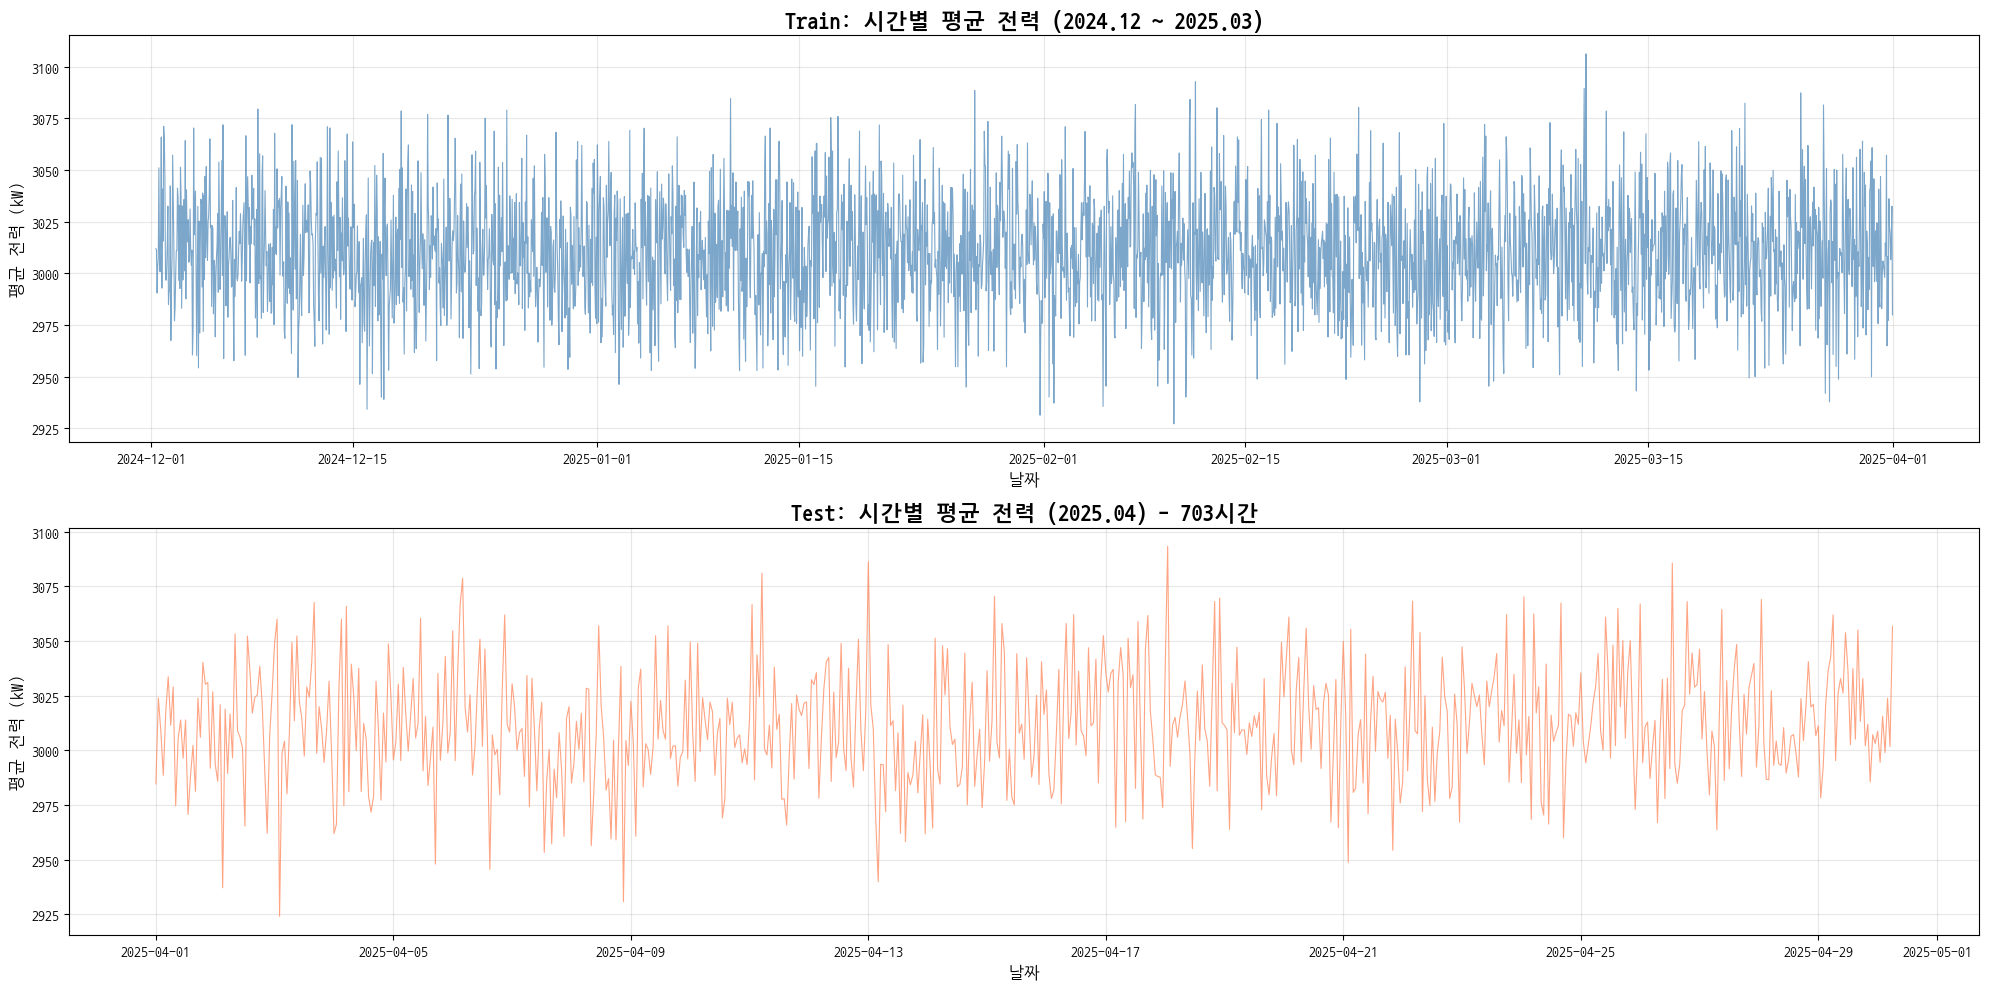


[최종 데이터 통계]
Train: 2896시간, 평균 3010.25 kW
Test: 703시간, 평균 3011.11 kW


In [ ]:
# ========================================
# 이상치 제거 후 최종 시각화
# ========================================

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Train
axes[0].plot(df_train_hourly['datetime'],
             df_train_hourly['activePower_mean'],
             linewidth=0.8, alpha=0.7, color='steelblue')
axes[0].set_title('Train: 시간별 평균 전력 (2024.12 ~ 2025.03)',
                  fontsize=16, weight='bold')
axes[0].set_xlabel('날짜', fontsize=12)
axes[0].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Test (정제 후)
axes[1].plot(df_test_hourly['datetime'],
             df_test_hourly['activePower_mean'],
             linewidth=0.8, alpha=0.7, color='coral')
axes[1].set_title(f'Test: 시간별 평균 전력 (2025.04) - {len(df_test_hourly)}시간',
                  fontsize=16, weight='bold')
axes[1].set_xlabel('날짜', fontsize=12)
axes[1].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/figures/01_timeseries_overview.png',
            dpi=300, bbox_inches='tight')
plt.show()

# 최종 통계
print("\n[최종 데이터 통계]")
print(f"Train: {len(df_train_hourly)}시간, 평균 {df_train_hourly['activePower_mean'].mean():.2f} kW")
print(f"Test: {len(df_test_hourly)}시간, 평균 {df_test_hourly['activePower_mean'].mean():.2f} kW")

⏰ 시간대별 패턴 분석

[시간대별 평균 전력]
    hour         mean        std          min          max  count
0      0  3009.062089  27.489964  2934.156236  3071.916083    120
1      1  3007.903436  26.973395  2927.116861  3080.149056    120
2      2  3010.623299  27.146140  2952.913986  3078.604833    120
3      3  3014.694865  28.635798  2935.559792  3074.477056    120
4      4  3011.229512  28.032760  2938.990639  3084.215681    120
5      5  3012.382019  30.139169  2948.782681  3088.528417    120
6      6  3010.156947  26.748042  2947.802097  3084.653139    120
7      7  3005.102322  24.318739  2941.879292  3068.471333    120
8      8  3012.515929  24.647171  2945.359611  3070.106097    121
9      9  3009.749435  26.638631  2940.120486  3081.762542    121
10    10  3007.781080  24.853031  2949.975597  3079.559611    121
11    11  3008.758827  24.662898  2956.126806  3066.030528    121
12    12  3011.408421  26.266694  2946.227278  3070.979000    121
13    13  3012.759284  29.449029  2953.163819  30

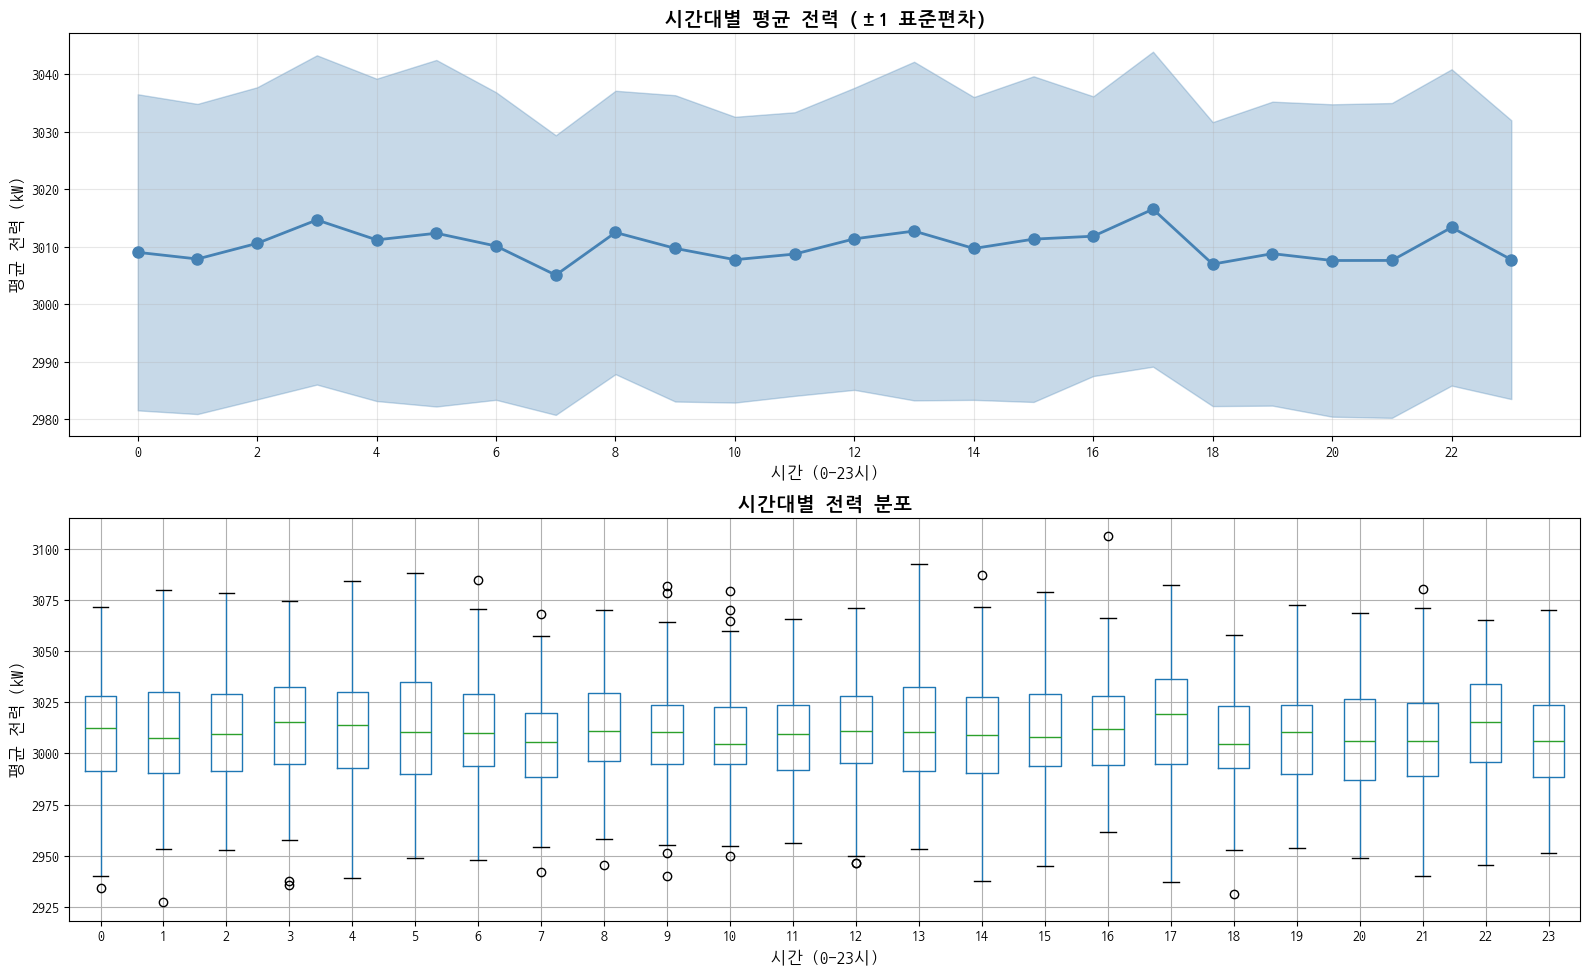


[주요 시간대]
피크 시간: 17시 (3016.56 kW)
최저 시간: 7시 (3005.10 kW)
차이: 11.46 kW (0.4%)

✅ 시간대별 패턴 분석 완료!


In [ ]:
# ========================================
# 2. 시간대별 패턴 분석
# ========================================

from src.eda.aggregation import aggregate_by_hour_of_day

print("="*60)
print("⏰ 시간대별 패턴 분석")
print("="*60)

# 시간대별 집계
hourly_pattern = aggregate_by_hour_of_day(df_train_hourly)

print("\n[시간대별 평균 전력]")
print(hourly_pattern)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1) 라인 차트
axes[0].plot(hourly_pattern['hour'], hourly_pattern['mean'],
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].fill_between(hourly_pattern['hour'],
                      hourly_pattern['mean'] - hourly_pattern['std'],
                      hourly_pattern['mean'] + hourly_pattern['std'],
                      alpha=0.3, color='steelblue')
axes[0].set_title('시간대별 평균 전력 (±1 표준편차)', fontsize=14, weight='bold')
axes[0].set_xlabel('시간 (0-23시)', fontsize=12)
axes[0].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# 2) 박스플롯
df_train_hourly.boxplot(column='activePower_mean', by='hour', ax=axes[1])
axes[1].set_title('시간대별 전력 분포', fontsize=14, weight='bold')
axes[1].set_xlabel('시간 (0-23시)', fontsize=12)
axes[1].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[1].get_figure().suptitle('')  # 기본 제목 제거

plt.tight_layout()
plt.savefig('./results/figures/02_hourly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# 피크/저점 시간 찾기
peak_hour = hourly_pattern.loc[hourly_pattern['mean'].idxmax()]
low_hour = hourly_pattern.loc[hourly_pattern['mean'].idxmin()]

print("\n[주요 시간대]")
print(f"피크 시간: {int(peak_hour['hour'])}시 ({peak_hour['mean']:.2f} kW)")
print(f"최저 시간: {int(low_hour['hour'])}시 ({low_hour['mean']:.2f} kW)")
print(f"차이: {peak_hour['mean'] - low_hour['mean']:.2f} kW ({(peak_hour['mean'] - low_hour['mean']) / low_hour['mean'] * 100:.1f}%)")

print("\n✅ 시간대별 패턴 분석 완료!")

📅 요일별 패턴 분석

[요일별 평균 전력]
   weekday weekday_name         mean        std  count
0        0            월  3010.760816  27.656459    432
1        1            화  3008.842299  27.053781    408
2        2            수  3010.631152  25.938190    408
3        3            목  3011.416174  26.737152    408
4        4            금  3010.804280  27.132786    408
5        5            토  3009.350012  25.890347    408
6        6            일  3009.917531  26.704493    424


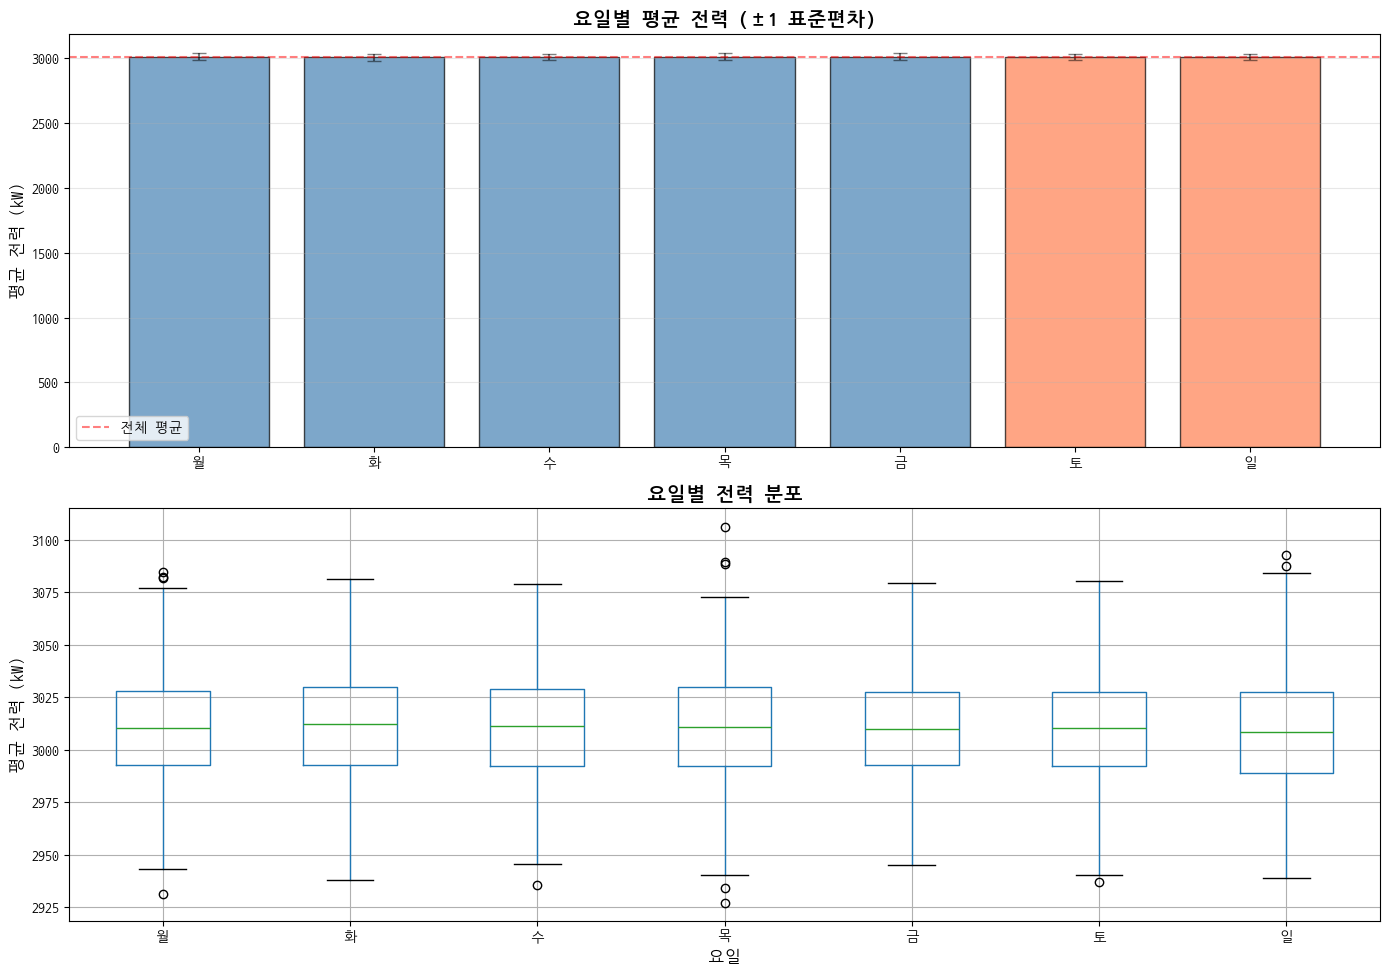


[평일 vs 주말]
평일 평균: 3010.49 kW
주말 평균: 3009.64 kW
차이: 0.85 kW (0.03%)

[주요 요일]
최고 요일: 목 (3011.42 kW)
최저 요일: 화 (3008.84 kW)
차이: 2.57 kW (0.09%)

✅ 요일별 패턴 분석 완료!


In [ ]:
# ========================================
# 3. 요일별 패턴 분석
# ========================================

from src.eda.aggregation import aggregate_by_weekday

print("="*60)
print("📅 요일별 패턴 분석")
print("="*60)

# 요일별 집계
weekday_pattern = aggregate_by_weekday(df_train_hourly)

print("\n[요일별 평균 전력]")
print(weekday_pattern[['weekday', 'weekday_name', 'mean', 'std', 'count']])

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1) 막대 차트
colors = ['steelblue' if i < 5 else 'coral' for i in range(7)]
axes[0].bar(weekday_pattern['weekday_name'], weekday_pattern['mean'],
            color=colors, alpha=0.7, edgecolor='black')
axes[0].errorbar(weekday_pattern['weekday_name'], weekday_pattern['mean'],
                 yerr=weekday_pattern['std'], fmt='none', color='black',
                 capsize=5, alpha=0.5)
axes[0].set_title('요일별 평균 전력 (±1 표준편차)', fontsize=14, weight='bold')
axes[0].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=df_train_hourly['activePower_mean'].mean(),
                color='red', linestyle='--', alpha=0.5, label='전체 평균')
axes[0].legend()

# 2) 박스플롯
df_train_hourly['weekday_name'] = df_train_hourly['weekday'].map({
    0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'
})
weekday_order = ['월', '화', '수', '목', '금', '토', '일']
df_train_hourly.boxplot(column='activePower_mean', by='weekday_name',
                         ax=axes[1], positions=range(7))
axes[1].set_xticklabels(weekday_order)
axes[1].set_title('요일별 전력 분포', fontsize=14, weight='bold')
axes[1].set_xlabel('요일', fontsize=12)
axes[1].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[1].get_figure().suptitle('')  # 기본 제목 제거

plt.tight_layout()
plt.savefig('./results/figures/03_weekday_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# 평일 vs 주말
weekday_avg = df_train_hourly[df_train_hourly['is_weekend'] == 0]['activePower_mean'].mean()
weekend_avg = df_train_hourly[df_train_hourly['is_weekend'] == 1]['activePower_mean'].mean()

print("\n[평일 vs 주말]")
print(f"평일 평균: {weekday_avg:.2f} kW")
print(f"주말 평균: {weekend_avg:.2f} kW")
print(f"차이: {abs(weekday_avg - weekend_avg):.2f} kW ({abs(weekday_avg - weekend_avg)/weekday_avg*100:.2f}%)")

# 최고/최저 요일
max_day = weekday_pattern.loc[weekday_pattern['mean'].idxmax()]
min_day = weekday_pattern.loc[weekday_pattern['mean'].idxmin()]

print("\n[주요 요일]")
print(f"최고 요일: {max_day['weekday_name']} ({max_day['mean']:.2f} kW)")
print(f"최저 요일: {min_day['weekday_name']} ({min_day['mean']:.2f} kW)")
print(f"차이: {max_day['mean'] - min_day['mean']:.2f} kW ({(max_day['mean'] - min_day['mean'])/min_day['mean']*100:.2f}%)")

print("\n✅ 요일별 패턴 분석 완료!")

📆 월별 패턴 분석

[월별 평균 전력]
   month month_name         mean        std  count
0      1         1월  3010.081682  27.048358    744
1      2         2월  3009.927951  27.192427    672
2      3         3월  3010.634598  26.600419    744
3     12        12월  3010.319469  26.154500    736


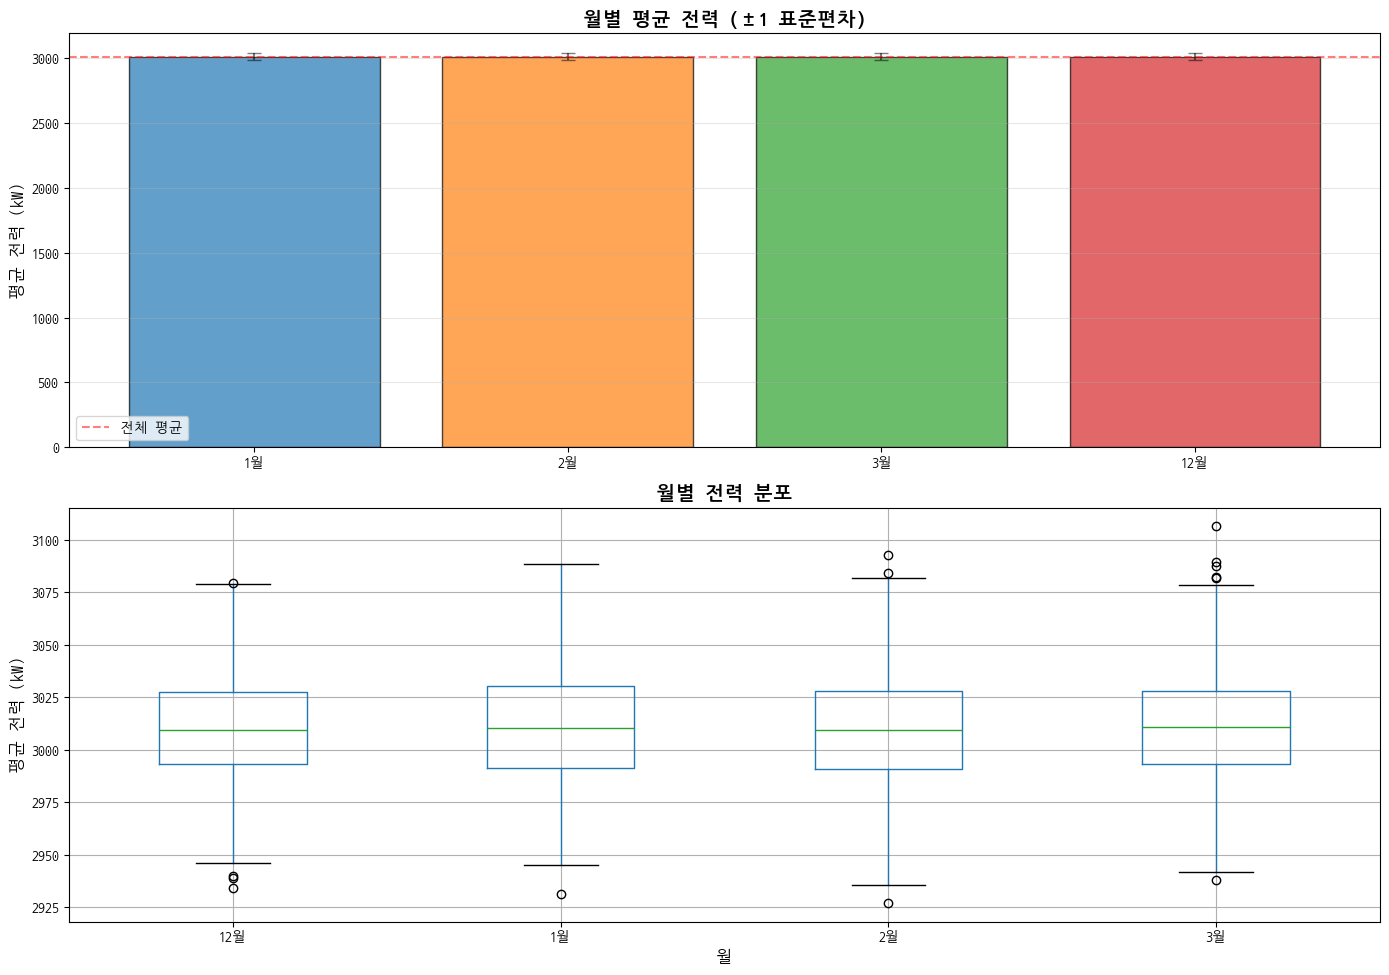


[주요 월]
최고 월: 3월 (3010.63 kW)
최저 월: 2월 (3009.93 kW)
차이: 0.71 kW (0.02%)

[계절 비교]
겨울 평균 (12-2월): 3010.12 kW
봄 평균 (3월): 3010.63 kW
차이: 0.52 kW (0.02%)

Test 평균 (4월): 3011.11 kW
Train 평균 대비: 0.86 kW

✅ 월별 패턴 분석 완료!


In [ ]:
# ========================================
# 4. 월별 패턴 분석
# ========================================

print("="*60)
print("📆 월별 패턴 분석")
print("="*60)

# 월별 집계
monthly_pattern = df_train_hourly.groupby('month')['activePower_mean'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).reset_index()

# 월 이름 추가
month_names = {12: '12월', 1: '1월', 2: '2월', 3: '3월'}
monthly_pattern['month_name'] = monthly_pattern['month'].map(month_names)

print("\n[월별 평균 전력]")
print(monthly_pattern[['month', 'month_name', 'mean', 'std', 'count']])

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1) 막대 차트
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[0].bar(monthly_pattern['month_name'], monthly_pattern['mean'],
            color=colors, alpha=0.7, edgecolor='black')
axes[0].errorbar(monthly_pattern['month_name'], monthly_pattern['mean'],
                 yerr=monthly_pattern['std'], fmt='none', color='black',
                 capsize=5, alpha=0.5)
axes[0].set_title('월별 평균 전력 (±1 표준편차)', fontsize=14, weight='bold')
axes[0].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=df_train_hourly['activePower_mean'].mean(),
                color='red', linestyle='--', alpha=0.5, label='전체 평균')
axes[0].legend()

# 2) 박스플롯
df_train_hourly['month_name'] = df_train_hourly['month'].map(month_names)
month_order = ['12월', '1월', '2월', '3월']
df_train_hourly.boxplot(column='activePower_mean', by='month_name',
                         ax=axes[1], positions=range(4))
axes[1].set_xticklabels(month_order)
axes[1].set_title('월별 전력 분포', fontsize=14, weight='bold')
axes[1].set_xlabel('월', fontsize=12)
axes[1].set_ylabel('평균 전력 (kW)', fontsize=12)
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.savefig('./results/figures/04_monthly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# 최고/최저 월
max_month = monthly_pattern.loc[monthly_pattern['mean'].idxmax()]
min_month = monthly_pattern.loc[monthly_pattern['mean'].idxmin()]

print("\n[주요 월]")
print(f"최고 월: {max_month['month_name']} ({max_month['mean']:.2f} kW)")
print(f"최저 월: {min_month['month_name']} ({min_month['mean']:.2f} kW)")
print(f"차이: {max_month['mean'] - min_month['mean']:.2f} kW ({(max_month['mean'] - min_month['mean'])/min_month['mean']*100:.2f}%)")

# 겨울(12-2월) vs 봄(3월)
winter_avg = df_train_hourly[df_train_hourly['month'].isin([12, 1, 2])]['activePower_mean'].mean()
spring_avg = df_train_hourly[df_train_hourly['month'] == 3]['activePower_mean'].mean()

print("\n[계절 비교]")
print(f"겨울 평균 (12-2월): {winter_avg:.2f} kW")
print(f"봄 평균 (3월): {spring_avg:.2f} kW")
print(f"차이: {abs(winter_avg - spring_avg):.2f} kW ({abs(winter_avg - spring_avg)/winter_avg*100:.2f}%)")

# Test(4월) 비교
test_avg = df_test_hourly['activePower_mean'].mean()
print(f"\nTest 평균 (4월): {test_avg:.2f} kW")
print(f"Train 평균 대비: {test_avg - df_train_hourly['activePower_mean'].mean():.2f} kW")

print("\n✅ 월별 패턴 분석 완료!")

📊 전력 변동성 분석

[전체 변동 통계]
평균: 3010.25 kW
표준편차: 26.73 kW (0.89%)
범위: 2927.12 ~ 3106.27 kW
변동폭: 179.16 kW (5.95%)

[시간 내 평균 변동 (5초 데이터 기준)]
평균 표준편차: 716.67 kW (23.81%)
최대 표준편차: 777.81 kW
최소 표준편차: 648.65 kW

평균 변동폭 (Max-Min): 3791.71 kW (125.96%)
평균 변동계수(CV): 23.81%


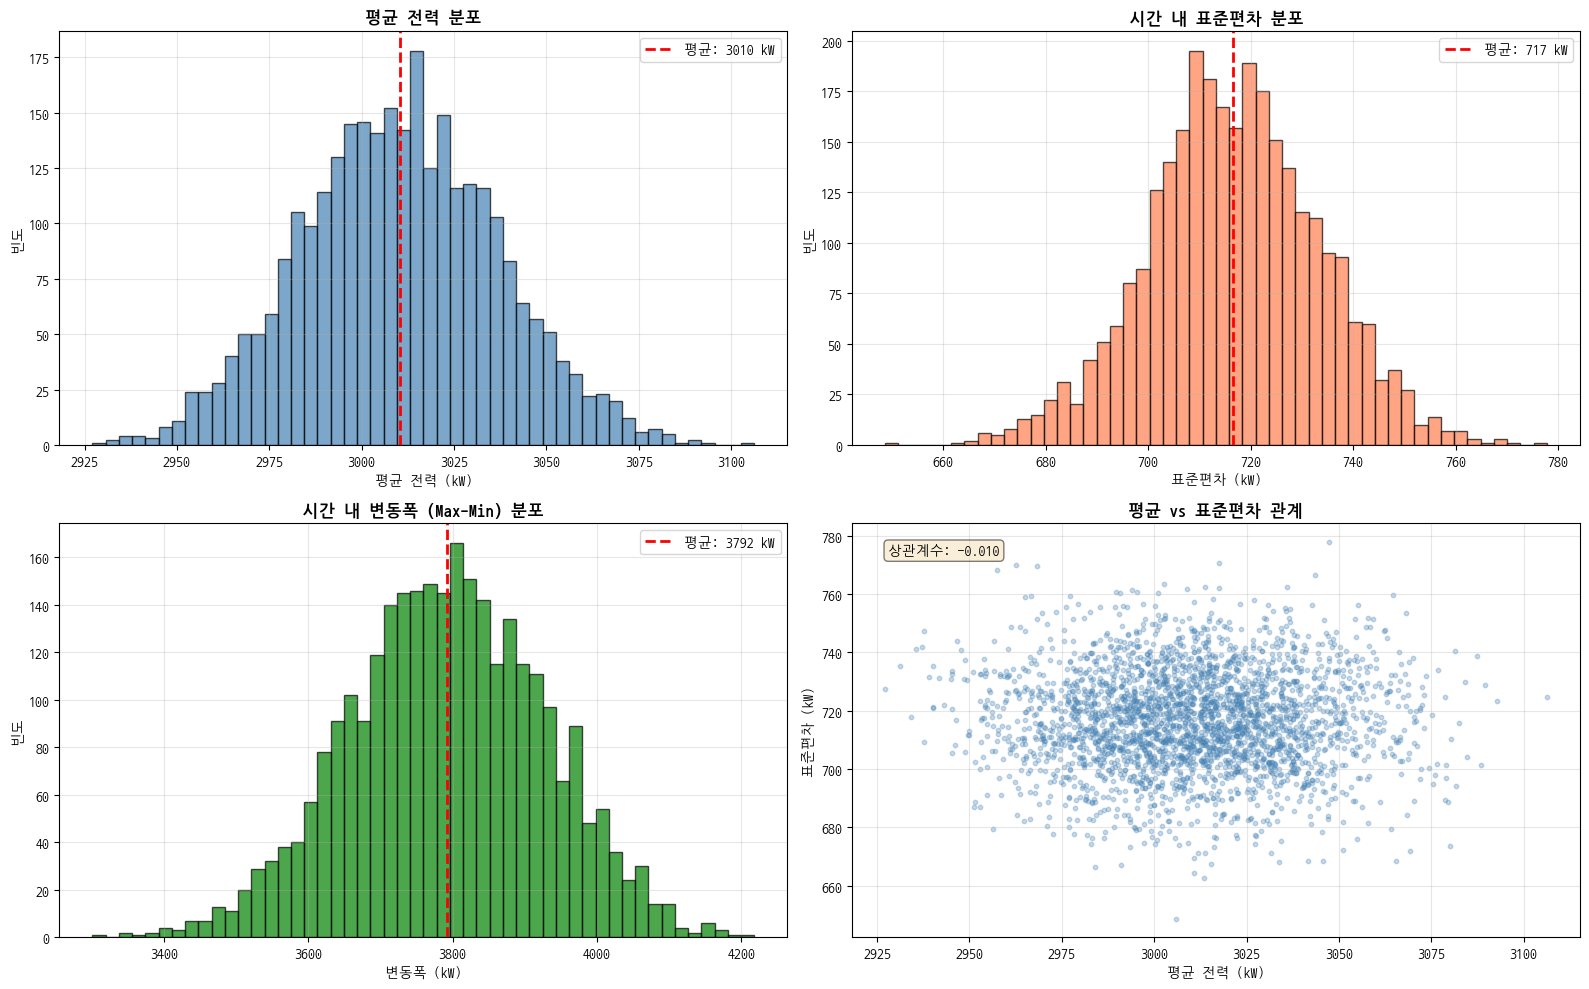


✅ 변동성 분석 완료!


In [ ]:
# ========================================
# 5. 변동성 분석
# ========================================

print("="*60)
print("📊 전력 변동성 분석")
print("="*60)

# 기본 통계
print("\n[전체 변동 통계]")
mean_power = df_train_hourly['activePower_mean'].mean()
std_power = df_train_hourly['activePower_mean'].std()
min_power = df_train_hourly['activePower_mean'].min()
max_power = df_train_hourly['activePower_mean'].max()

print(f"평균: {mean_power:.2f} kW")
print(f"표준편차: {std_power:.2f} kW ({std_power/mean_power*100:.2f}%)")
print(f"범위: {min_power:.2f} ~ {max_power:.2f} kW")
print(f"변동폭: {max_power - min_power:.2f} kW ({(max_power - min_power)/mean_power*100:.2f}%)")

# 시간 내 변동
print(f"\n[시간 내 평균 변동 (5초 데이터 기준)]")
mean_std = df_train_hourly['activePower_std'].mean()
print(f"평균 표준편차: {mean_std:.2f} kW ({mean_std/mean_power*100:.2f}%)")
print(f"최대 표준편차: {df_train_hourly['activePower_std'].max():.2f} kW")
print(f"최소 표준편차: {df_train_hourly['activePower_std'].min():.2f} kW")

# 변동폭 계산
df_train_hourly['range'] = df_train_hourly['activePower_max'] - df_train_hourly['activePower_min']
mean_range = df_train_hourly['range'].mean()
print(f"\n평균 변동폭 (Max-Min): {mean_range:.2f} kW ({mean_range/mean_power*100:.2f}%)")

# 변동계수
df_train_hourly['cv'] = df_train_hourly['activePower_std'] / df_train_hourly['activePower_mean'] * 100
print(f"평균 변동계수(CV): {df_train_hourly['cv'].mean():.2f}%")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 평균 전력 분포
axes[0, 0].hist(df_train_hourly['activePower_mean'], bins=50,
                color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(mean_power, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_power:.0f} kW')
axes[0, 0].set_title('평균 전력 분포', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('평균 전력 (kW)', fontsize=10)
axes[0, 0].set_ylabel('빈도', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2) 표준편차 분포
axes[0, 1].hist(df_train_hourly['activePower_std'], bins=50,
                color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(mean_std, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_std:.0f} kW')
axes[0, 1].set_title('시간 내 표준편차 분포', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('표준편차 (kW)', fontsize=10)
axes[0, 1].set_ylabel('빈도', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3) 변동폭 분포
axes[1, 0].hist(df_train_hourly['range'], bins=50,
                color='green', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(mean_range, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_range:.0f} kW')
axes[1, 0].set_title('시간 내 변동폭 (Max-Min) 분포', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('변동폭 (kW)', fontsize=10)
axes[1, 0].set_ylabel('빈도', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4) Mean vs Std 산점도
axes[1, 1].scatter(df_train_hourly['activePower_mean'],
                   df_train_hourly['activePower_std'],
                   alpha=0.3, s=10, color='steelblue')
axes[1, 1].set_title('평균 vs 표준편차 관계', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('평균 전력 (kW)', fontsize=10)
axes[1, 1].set_ylabel('표준편차 (kW)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# 상관계수
corr = df_train_hourly[['activePower_mean', 'activePower_std']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'상관계수: {corr:.3f}',
                transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('./results/figures/05_volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 변동성 분석 완료!")

📈 자기상관 분석 (ACF/PACF)


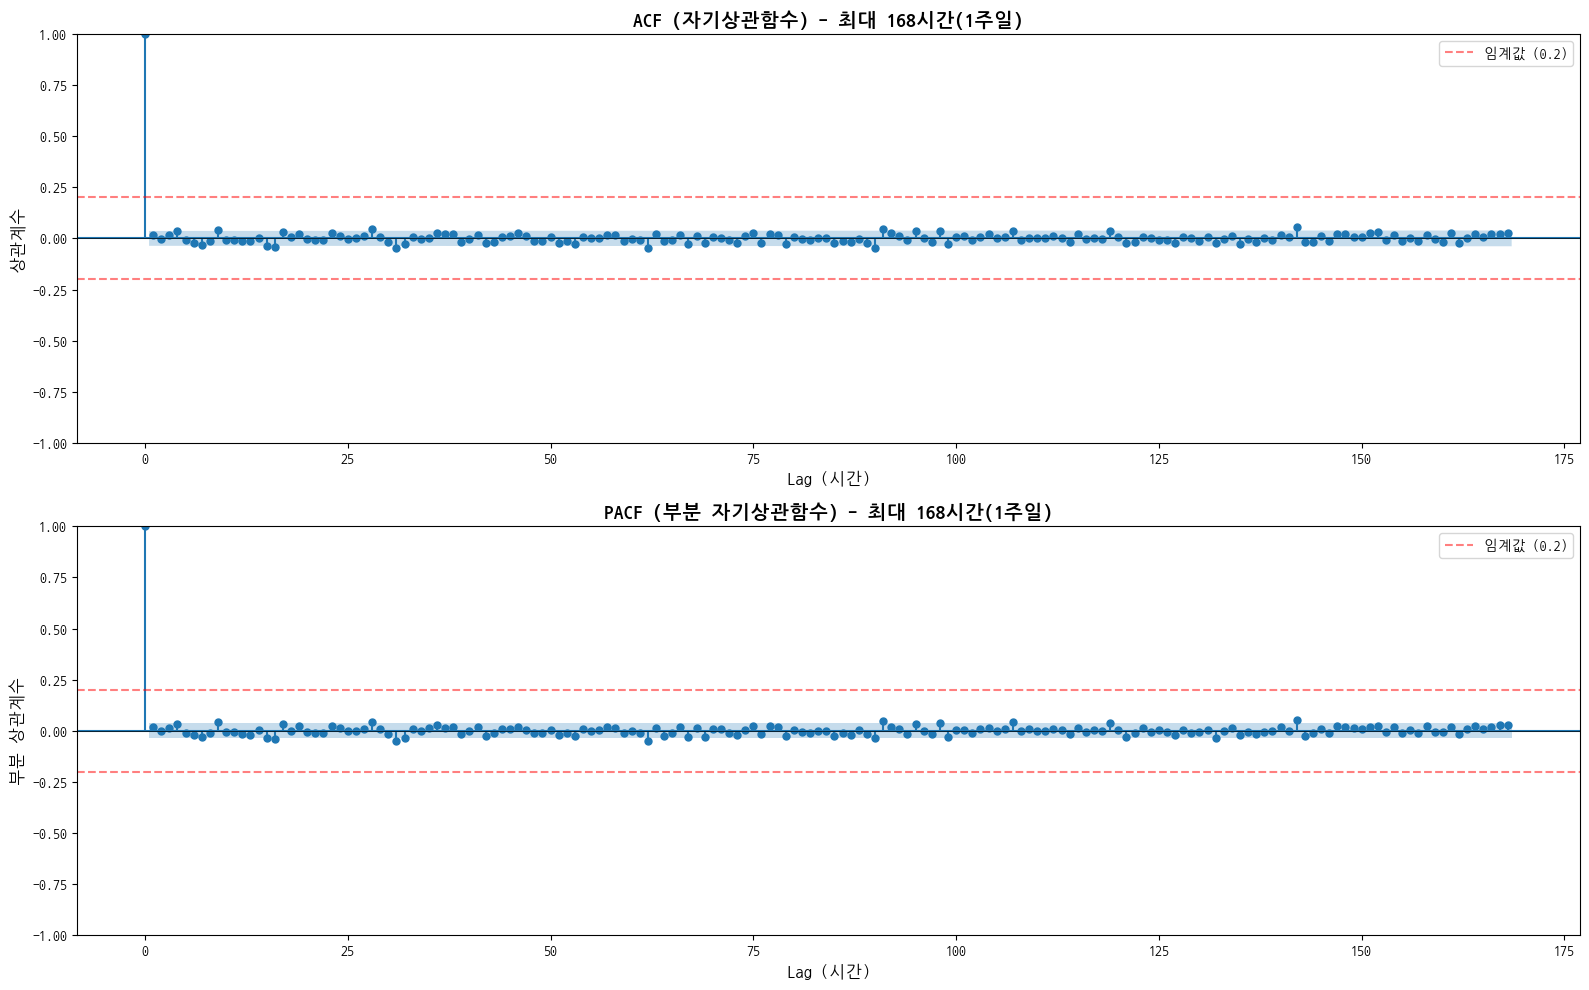


[원본 데이터 - 주요 Lag 상관계수]
  Lag      ACF     PACF
-------------------------
    1    0.018    0.018
    2   -0.001   -0.001
    3    0.014    0.014
    6   -0.021   -0.020
   12   -0.014   -0.015
   24    0.013    0.016
   48   -0.014   -0.012
   72   -0.009   -0.012
  168    0.026    0.029

→ 원본 데이터는 상관관계 매우 낮음 (평균 안정적)

📊 차분 후 ACF/PACF 분석


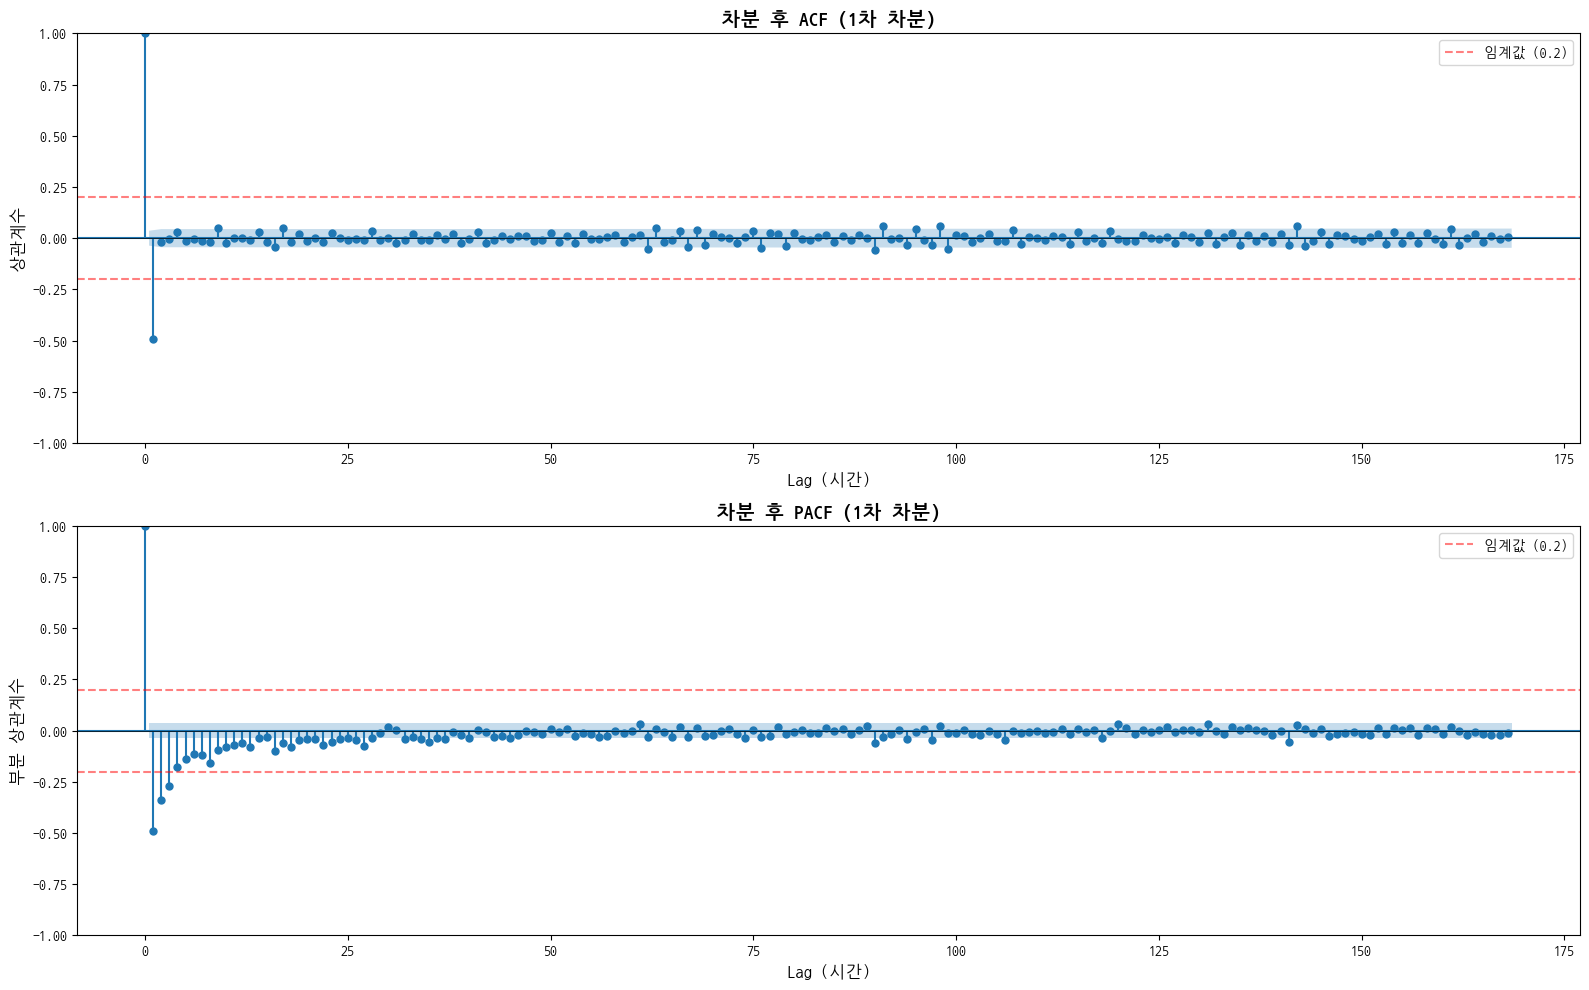


[차분 후 주요 Lag 상관계수]
  Lag      ACF     PACF
-------------------------
    1   -0.490   -0.491
    2   -0.017   -0.339
    3   -0.003   -0.269
    6   -0.002   -0.115
   12   -0.001   -0.063
   24    0.000   -0.043
   48   -0.015   -0.011
   72    0.000    0.005
  168    0.003   -0.063

→ Lag 1: -0.49 (음의 상관, 반전 패턴!)
→ Lag 2-3: PACF 높음 (직접 영향)

📊 변동성(std) ACF 분석


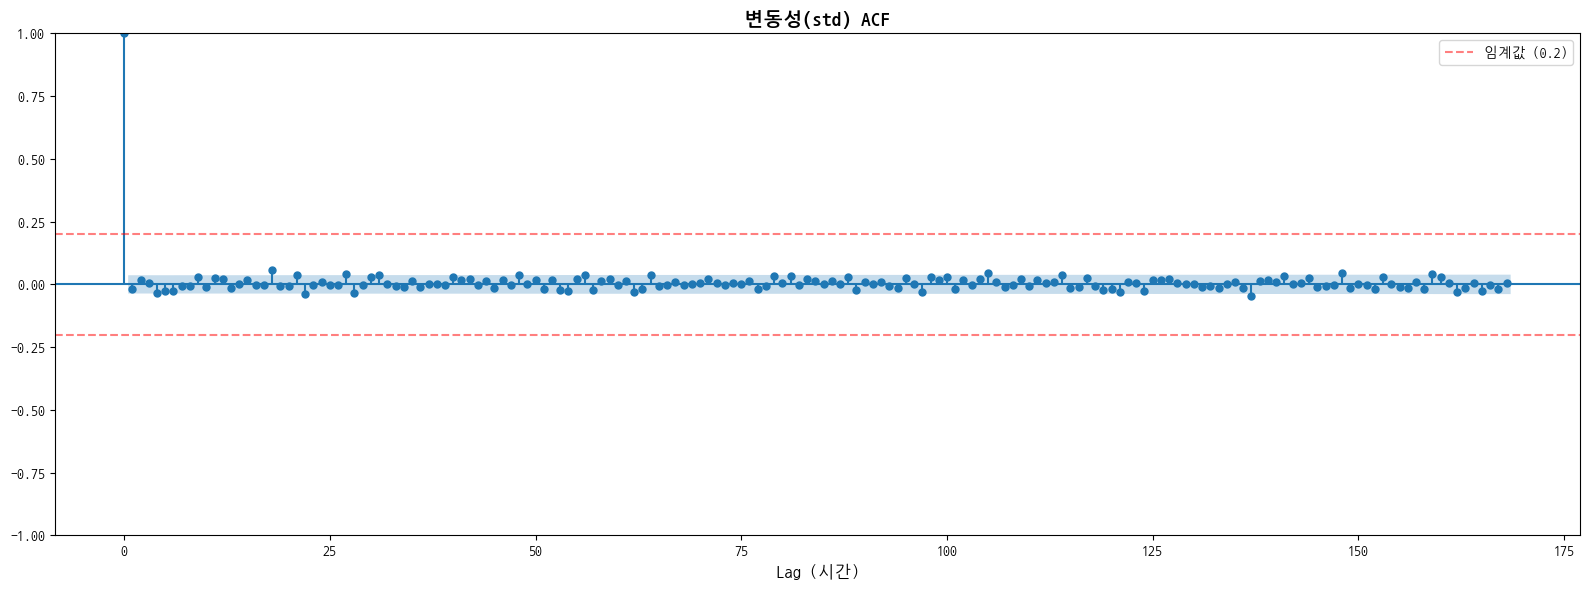


[변동성 주요 Lag 상관계수]
  Lag      ACF
---------------
    1   -0.017
    2    0.018
    3    0.005
    6   -0.026
   12    0.023
   24    0.009
   48    0.037
   72    0.005
  168    0.004

→ 변동성도 상관관계 매우 낮음

💡 Lag Feature 전략

✅ 추천 Feature:

1. Lag Features (필수)
   - power_lag_1h  (가장 중요! 반전 패턴)
   - power_lag_2h
   - power_lag_3h

2. Rolling Features
   - rolling_mean_6h
   - rolling_mean_24h
   - rolling_std_24h

3. 차분 Features (선택)
   - power_diff_1h

4. 물리 기반 Features
   - efficiency
   - power_calculated

❌ 제외:
   - lag_24h (일일 패턴 없음)
   - lag_168h (주간 패턴 없음)

✅ 자기상관 분석 완료!


In [ ]:
# ========================================
# 6. 자기상관 분석 (ACF/PACF)
# ========================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

print("="*60)
print("📈 자기상관 분석 (ACF/PACF)")
print("="*60)

# ACF/PACF 계산
acf_values = acf(df_train_hourly['activePower_mean'], nlags=168)
pacf_values = pacf(df_train_hourly['activePower_mean'], nlags=168)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1) ACF (자기상관함수)
plot_acf(df_train_hourly['activePower_mean'], lags=168, ax=axes[0])
axes[0].set_title('ACF (자기상관함수) - 최대 168시간(1주일)', fontsize=14, weight='bold')
axes[0].set_xlabel('Lag (시간)', fontsize=12)
axes[0].set_ylabel('상관계수', fontsize=12)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='임계값 (0.2)')
axes[0].axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

# 2) PACF (부분 자기상관함수)
plot_pacf(df_train_hourly['activePower_mean'], lags=168, ax=axes[1], method='ywm')
axes[1].set_title('PACF (부분 자기상관함수) - 최대 168시간(1주일)', fontsize=14, weight='bold')
axes[1].set_xlabel('Lag (시간)', fontsize=12)
axes[1].set_ylabel('부분 상관계수', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='임계값 (0.2)')
axes[1].axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('./results/figures/06_acf_pacf_original.png', dpi=300, bbox_inches='tight')
plt.show()

# 주요 Lag 상관계수
print("\n[원본 데이터 - 주요 Lag 상관계수]")
print(f"{'Lag':>5} {'ACF':>8} {'PACF':>8}")
print("-" * 25)
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    if lag < len(acf_values):
        print(f"{lag:>5} {acf_values[lag]:>8.3f} {pacf_values[lag]:>8.3f}")

print("\n→ 원본 데이터는 상관관계 매우 낮음 (평균 안정적)")

# ========================================
# 차분 후 ACF/PACF
# ========================================

print("\n" + "="*60)
print("📊 차분 후 ACF/PACF 분석")
print("="*60)

# 1차 차분
df_train_hourly['power_diff'] = df_train_hourly['activePower_mean'].diff()

# 차분 데이터 ACF/PACF
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_acf(df_train_hourly['power_diff'].dropna(), lags=168, ax=axes[0])
axes[0].set_title('차분 후 ACF (1차 차분)', fontsize=14, weight='bold')
axes[0].set_xlabel('Lag (시간)', fontsize=12)
axes[0].set_ylabel('상관계수', fontsize=12)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='임계값 (0.2)')
axes[0].axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

plot_pacf(df_train_hourly['power_diff'].dropna(), lags=168, ax=axes[1], method='ywm')
axes[1].set_title('차분 후 PACF (1차 차분)', fontsize=14, weight='bold')
axes[1].set_xlabel('Lag (시간)', fontsize=12)
axes[1].set_ylabel('부분 상관계수', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='임계값 (0.2)')
axes[1].axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('./results/figures/06_acf_pacf_diff.png', dpi=300, bbox_inches='tight')
plt.show()

# 차분 후 상관계수
acf_diff = acf(df_train_hourly['power_diff'].dropna(), nlags=168)
pacf_diff = pacf(df_train_hourly['power_diff'].dropna(), nlags=168)

print("\n[차분 후 주요 Lag 상관계수]")
print(f"{'Lag':>5} {'ACF':>8} {'PACF':>8}")
print("-" * 25)
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    if lag < len(acf_diff):
        print(f"{lag:>5} {acf_diff[lag]:>8.3f} {pacf_diff[lag]:>8.3f}")

print("\n→ Lag 1: -0.49 (음의 상관, 반전 패턴!)")
print("→ Lag 2-3: PACF 높음 (직접 영향)")

# ========================================
# 변동성(std) ACF
# ========================================

print("\n" + "="*60)
print("📊 변동성(std) ACF 분석")
print("="*60)

acf_std = acf(df_train_hourly['activePower_std'], nlags=168)

fig, ax = plt.subplots(figsize=(16, 6))
plot_acf(df_train_hourly['activePower_std'], lags=168, ax=ax)
ax.set_title('변동성(std) ACF', fontsize=14, weight='bold')
ax.set_xlabel('Lag (시간)', fontsize=12)
ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='임계값 (0.2)')
ax.axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('./results/figures/06_acf_std.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[변동성 주요 Lag 상관계수]")
print(f"{'Lag':>5} {'ACF':>8}")
print("-" * 15)
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    if lag < len(acf_std):
        print(f"{lag:>5} {acf_std[lag]:>8.3f}")

print("\n→ 변동성도 상관관계 매우 낮음")

# ========================================
# Feature 추천
# ========================================

print("\n" + "="*60)
print("💡 Lag Feature 전략")
print("="*60)

print("\n✅ 추천 Feature:")
print("\n1. Lag Features (필수)")
print("   - power_lag_1h  (가장 중요! 반전 패턴)")
print("   - power_lag_2h")
print("   - power_lag_3h")

print("\n2. Rolling Features")
print("   - rolling_mean_6h")
print("   - rolling_mean_24h")
print("   - rolling_std_24h")

print("\n3. 차분 Features (선택)")
print("   - power_diff_1h")

print("\n4. 물리 기반 Features")
print("   - efficiency")
print("   - power_calculated")

print("\n❌ 제외:")
print("   - lag_24h (일일 패턴 없음)")
print("   - lag_168h (주간 패턴 없음)")

print("\n✅ 자기상관 분석 완료!")